# PLS Regression — Interpretação dos resultados
**Grupo 1 | Bitcoin diário**

Interpreta a configuração e as métricas walk-forward já produzidas pelo pipeline PLS, além de examinar coeficientes, VIP e permutation importance no conjunto de features. A importância por permutação é calculada depois de fixado o modelo e não é usada para escolher hiperparâmetros. Os resultados e gráficos permanecem no notebook; nenhum arquivo é gravado.

PLS: 9 componentes | treino: 1996 | teste: 856 | features: 51
Selecao no treino: MAE_CV USD 1,982.29 (± USD 1,412.91)

Top 15 features por VIP, com coeficientes e importancia por permutacao:


,tipo_feature,coeficiente,VIP,permutation_importance_mae,permutation_std
close_lag1,Historico/preco,0.152826,1.598915,1878.263795,54.476244
close_lag2,Historico/preco,0.139556,1.594380,1609.088052,52.216436
close_lag3,Historico/preco,0.127383,1.589811,1381.424403,51.129699
close_ma7,Historico/preco,0.117571,1.588447,1197.021163,45.339484
close_lag5,Historico/preco,0.103138,1.580753,958.915183,38.727478
close_ma14,Historico/preco,0.093487,1.578273,785.398749,30.648893
close_lag7,Historico/preco,0.085309,1.572618,686.421460,25.506643
close_ma21,Historico/preco,0.077134,1.569105,544.520241,21.361616
close_ma30,Historico/preco,0.059485,1.557918,330.581519,10.344930
close_lag14,Historico/preco,0.051435,1.547888,247.785843,9.863104



Desempenho oficial fora da amostra:


,metrica,valor
0,MAE walk-forward (USD),2608.614507
1,RMSE walk-forward (USD),3521.843601
2,MAPE walk-forward (%),3.157609
3,R2 walk-forward,0.965351
4,"Vies (real - previsto, USD)",-336.247160
5,Componentes selecionados,9.000000


Periodo de previsao: 2024-05-08 a 2026-09-10 (856 previsoes)

Ljung-Box dos residuos walk-forward (H0: sem autocorrelacao ate o lag):


,lag,Estatística Q (LB),p-valor,Conclusão (α=0.05)
0,1,505.658311,5.582768e-112,❌ Autocorrelação Residual (p ≤ 0.05)
1,3,928.315596,6.383879e-201,❌ Autocorrelação Residual (p ≤ 0.05)
2,5,1167.307713,3.540488e-250,❌ Autocorrelação Residual (p ≤ 0.05)
3,7,1328.784863,9.866280e-283,❌ Autocorrelação Residual (p ≤ 0.05)
4,14,1609.021676,0.000000e+00,❌ Autocorrelação Residual (p ≤ 0.05)
5,21,1667.059645,0.000000e+00,❌ Autocorrelação Residual (p ≤ 0.05)
6,30,1688.151998,0.000000e+00,❌ Autocorrelação Residual (p ≤ 0.05)


Interpretacao: p-valor < 0,05 em ao menos um lag; rejeita-se H0 e resta autocorrelacao nos residuos.


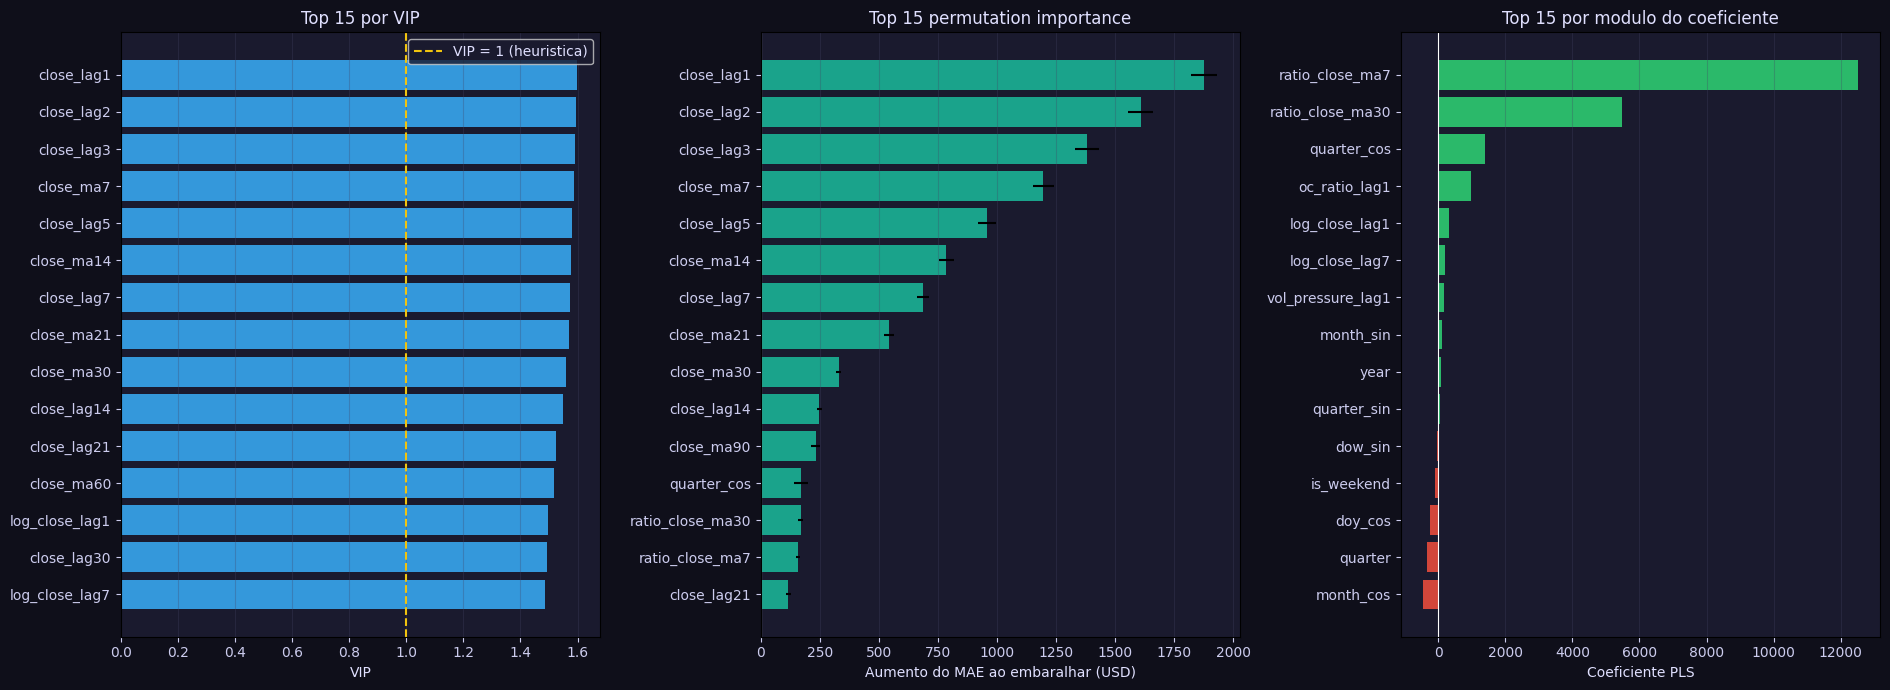

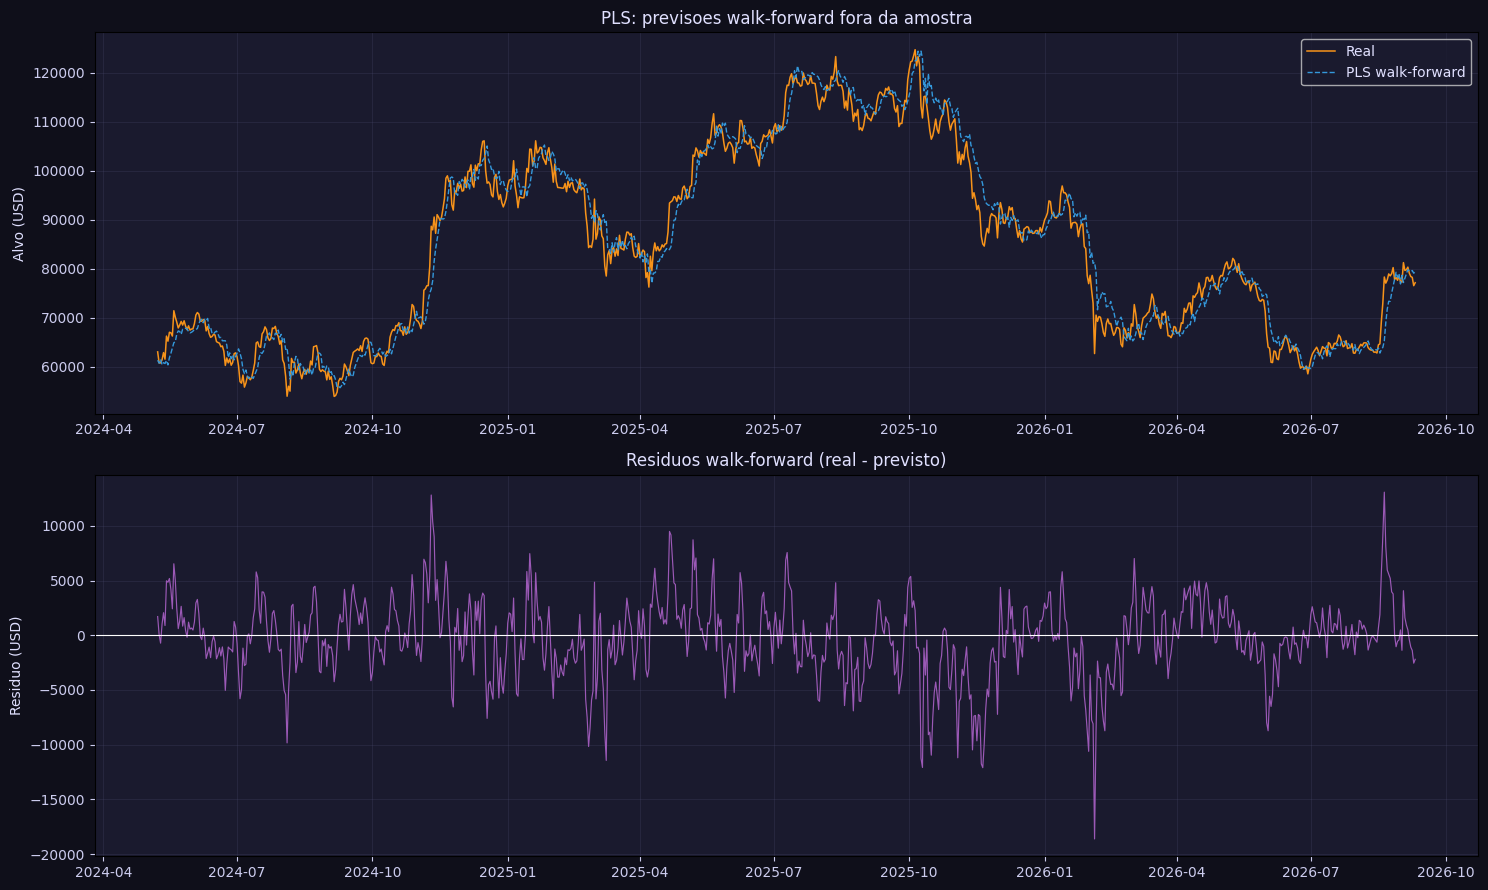


Leitura critica: as importancias descrevem associacao preditiva, nao causalidade. Como lags e medias moveis sao correlacionados, coeficientes, VIP e permutacao podem distribuir a importancia de formas diferentes. O Ljung-Box deve ser interpretado junto aos graficos e ao viés, nao como prova isolada de adequacao.


In [2]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cross_decomposition import PLSRegression
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error

warnings.filterwarnings('ignore')
RANDOM_STATE = 42

CWD = Path.cwd().resolve()
PROJECT_ROOT = next(
    (candidate for candidate in (CWD, *CWD.parents)
     if (candidate / 'analyses').is_dir() and (candidate / 'bases').is_dir()),
    None
)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Nao foi possivel localizar a raiz do projeto.')
DATA_DIR = PROJECT_ROOT / 'analyses' / 'grupo1' / '01_dados'
PLS_DIR = PROJECT_ROOT / 'analyses' / 'grupo1' / '02_modelos' / 'PLS_Regression'

required_files = [
    PLS_DIR / 'pls_config_final.json',
    PLS_DIR / 'pls_metricas_walkforward.json',
    PLS_DIR / 'pls_gridsearch_resultados.csv',
    PLS_DIR / 'pls_previsoes_walkforward.csv',
    PLS_DIR / 'pls_ljungbox_residuos.csv',
    DATA_DIR / 'feature_metadata.json',
    DATA_DIR / 'bitcoin_features_train.csv',
    DATA_DIR / 'bitcoin_features_test.csv'
]
missing_files = [str(path) for path in required_files if not path.is_file()]
if missing_files:
    raise FileNotFoundError('Faltam artefatos existentes do pipeline PLS: ' + ', '.join(missing_files))

with (PLS_DIR / 'pls_config_final.json').open('r', encoding='utf-8') as file:
    config = json.load(file)
with (PLS_DIR / 'pls_metricas_walkforward.json').open('r', encoding='utf-8') as file:
    metrics = json.load(file)
with (DATA_DIR / 'feature_metadata.json').open('r', encoding='utf-8') as file:
    metadata = json.load(file)

FEATURE_COLS = metadata['feature_cols']
TARGET_COL = metadata['target_col']
train = pd.read_csv(DATA_DIR / 'bitcoin_features_train.csv', parse_dates=['date']).sort_values('date').reset_index(drop=True)
test = pd.read_csv(DATA_DIR / 'bitcoin_features_test.csv', parse_dates=['date']).sort_values('date').reset_index(drop=True)
cv_results = pd.read_csv(PLS_DIR / 'pls_gridsearch_resultados.csv')
walkforward = pd.read_csv(PLS_DIR / 'pls_previsoes_walkforward.csv', parse_dates=['date']).sort_values('date').reset_index(drop=True)
ljung_box = pd.read_csv(PLS_DIR / 'pls_ljungbox_residuos.csv')

X_train = train[FEATURE_COLS].astype(float)
y_train = train[TARGET_COL].astype(float)
X_test = test[FEATURE_COLS].astype(float)
y_test = test[TARGET_COL].astype(float)
n_components = int(config['n_components'])
pls = PLSRegression(n_components=n_components, scale=bool(config['scale']))
pls.fit(X_train, y_train)

# PLS coefficients and VIP summarize the fitted latent directions.
coef = pd.Series(pls.coef_.ravel(), index=FEATURE_COLS, name='coeficiente')
weights = np.asarray(pls.x_weights_)
scores = np.asarray(pls.x_scores_)
loadings_y = np.asarray(pls.y_loadings_).reshape(-1)
ssy_components = np.sum(scores ** 2, axis=0) * (loadings_y ** 2)
weight_norms = np.sum(weights ** 2, axis=0)
if np.any(weight_norms == 0) or np.sum(ssy_components) == 0:
    raise ValueError('Nao foi possivel calcular VIP: componente degenerado.')
normalized_weights_sq = weights ** 2 / weight_norms[np.newaxis, :]
var_count = len(FEATURE_COLS)
vip = pd.Series(
    np.sqrt(var_count * (normalized_weights_sq @ ssy_components) / np.sum(ssy_components)),
    index=FEATURE_COLS,
    name='VIP'
)

# Permutation importance uses the frozen train fit and test only for interpretation.
permutation = permutation_importance(
    pls,
    X_test,
    y_test,
    scoring='neg_mean_absolute_error',
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
permutation_mean = pd.Series(
    permutation.importances_mean,
    index=FEATURE_COLS,
    name='permutation_importance_mae'
)
permutation_std = pd.Series(
    permutation.importances_std,
    index=FEATURE_COLS,
    name='permutation_std'
)

importance = pd.concat([coef, vip, permutation_mean, permutation_std], axis=1)
importance['tipo_feature'] = [
    'Volume/mercado' if name.startswith(('vol_', 'range_', 'return_', 'oc_', 'rsi_', 'vol_pressure'))
    else 'Calendario' if name.startswith(('day_', 'month', 'quarter', 'year', 'week_', 'dow_', 'doy_', 'is_weekend'))
    else 'Historico/preco' for name in importance.index
]
importance['abs_coeficiente'] = importance['coeficiente'].abs()
importance = importance.sort_values('VIP', ascending=False)

print(f'PLS: {n_components} componentes | treino: {len(train)} | teste: {len(test)} | features: {len(FEATURE_COLS)}')
print(f"Selecao no treino: MAE_CV USD {config['mae_cv']:,.2f} (± USD {config['mae_cv_std']:,.2f})")
print('\nTop 15 features por VIP, com coeficientes e importancia por permutacao:')
display(importance[['tipo_feature', 'coeficiente', 'VIP', 'permutation_importance_mae', 'permutation_std']].head(15))

# Confere previsoes persistidas e metricas oficiais do walk-forward.
if len(walkforward) != int(metrics['n_previsoes']):
    raise ValueError('O total de previsoes nao corresponde aos metadados walk-forward.')
walkforward_mae = mean_absolute_error(walkforward['priceClose_real'], walkforward['priceClose_pred_PLS'])
if not np.isclose(walkforward_mae, metrics['MAE'], rtol=1e-6):
    raise ValueError('MAE recalculado nao corresponde ao JSON de metricas walk-forward.')

metric_summary = pd.DataFrame([
    {'metrica': 'MAE walk-forward (USD)', 'valor': metrics['MAE']},
    {'metrica': 'RMSE walk-forward (USD)', 'valor': metrics['RMSE']},
    {'metrica': 'MAPE walk-forward (%)', 'valor': metrics['MAPE']},
    {'metrica': 'R2 walk-forward', 'valor': metrics['R2']},
    {'metrica': 'Vies (real - previsto, USD)', 'valor': metrics['Bias']},
    {'metrica': 'Componentes selecionados', 'valor': n_components}
])
print('\nDesempenho oficial fora da amostra:')
display(metric_summary)
print(f"Periodo de previsao: {walkforward['date'].min().date()} a {walkforward['date'].max().date()} ({len(walkforward)} previsoes)")

# Leitura do Ljung-Box e interpretacao p-valor por lag.
print('\nLjung-Box dos residuos walk-forward (H0: sem autocorrelacao ate o lag):')
display(ljung_box)
pvalue_column = next((column for column in ljung_box.columns if 'p-valor' in column.lower() or 'pvalor' in column.lower()), None)
if pvalue_column is None:
    raise KeyError('Nao encontrei a coluna de p-valor no CSV Ljung-Box.')
if (pd.to_numeric(ljung_box[pvalue_column], errors='coerce') < 0.05).any():
    print('Interpretacao: p-valor < 0,05 em ao menos um lag; rejeita-se H0 e resta autocorrelacao nos residuos.')
else:
    print('Interpretacao: nao ha evidencias para rejeitar H0 nos lags reportados.')

plt.rcParams.update({
    'figure.facecolor': '#0f0f1a', 'axes.facecolor': '#1a1a2e',
    'axes.labelcolor': '#e0e0ff', 'xtick.color': '#ccccee',
    'ytick.color': '#ccccee', 'text.color': '#e0e0ff', 'grid.color': '#444466'
})
fig, axes = plt.subplots(1, 3, figsize=(19, 7), facecolor='#0f0f1a')
axes[0].barh(importance.head(15).sort_values('VIP').index, importance.head(15).sort_values('VIP')['VIP'], color='#3498db')
axes[0].axvline(1, color='#f1c40f', ls='--', label='VIP = 1 (heuristica)')
axes[0].set_title('Top 15 por VIP')
axes[0].set_xlabel('VIP')
axes[0].grid(axis='x', alpha=0.3)
axes[0].legend()

perm_top = importance.reindex(importance['permutation_importance_mae'].abs().sort_values(ascending=False).head(15).index).sort_values('permutation_importance_mae')
axes[1].barh(perm_top.index, perm_top['permutation_importance_mae'], xerr=perm_top['permutation_std'], color='#1abc9c', alpha=0.85)
axes[1].axvline(0, color='white', lw=0.8)
axes[1].set_title('Top 15 permutation importance')
axes[1].set_xlabel('Aumento do MAE ao embaralhar (USD)')
axes[1].grid(axis='x', alpha=0.3)

coef_top = importance.reindex(importance['abs_coeficiente'].sort_values(ascending=False).head(15).index).sort_values('coeficiente')
colors = ['#2ecc71' if value >= 0 else '#e74c3c' for value in coef_top['coeficiente']]
axes[2].barh(coef_top.index, coef_top['coeficiente'], color=colors, alpha=0.9)
axes[2].axvline(0, color='white', lw=0.8)
axes[2].set_title('Top 15 por modulo do coeficiente')
axes[2].set_xlabel('Coeficiente PLS')
axes[2].grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Walk-forward real versus previsto e residuos.
fig, axes = plt.subplots(2, 1, figsize=(15, 9), facecolor='#0f0f1a')
axes[0].plot(walkforward['date'], walkforward['priceClose_real'], color='#f7931a', lw=1.1, label='Real')
axes[0].plot(walkforward['date'], walkforward['priceClose_pred_PLS'], color='#3498db', lw=1.0, ls='--', label='PLS walk-forward')
axes[0].set_title('PLS: previsoes walk-forward fora da amostra')
axes[0].set_ylabel('Alvo (USD)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[1].plot(walkforward['date'], walkforward['residuo_PLS'], color='#9b59b6', lw=0.85)
axes[1].axhline(0, color='white', lw=0.8)
axes[1].set_title('Residuos walk-forward (real - previsto)')
axes[1].set_ylabel('Residuo (USD)')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\nLeitura critica: as importancias descrevem associacao preditiva, nao causalidade. Como lags e medias moveis sao correlacionados, coeficientes, VIP e permutacao podem distribuir a importancia de formas diferentes. O Ljung-Box deve ser interpretado junto aos graficos e ao viés, nao como prova isolada de adequacao.')